**Import Libraries**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [15]:
df = pd.read_csv("/content/HousingData.csv")

**Data Processing**

In [17]:
# Check missing values
print(df.isnull().sum())

# Define X (features) and y (target)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


**Train_Test Split**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train **Model**

In [20]:
from sklearn.impute import SimpleImputer

# Impute missing values in X_train and X_test using the mean of X_train
# Create an imputer that fills missing values with the mean of the column
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on X_train and transform X_train
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame to preserve column names if desired for later steps
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Prediction**

In [21]:
y_pred = model.predict(X_test)

print("Predicted values:\n", y_pred[:5])

Predicted values:
 [29.14910712 36.53310251 14.4858616  25.07692337 18.44762736]


**Modal Evolution**

In [23]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 25.002388923514886
R2 Score: 0.6590604241860202


**Visualization**

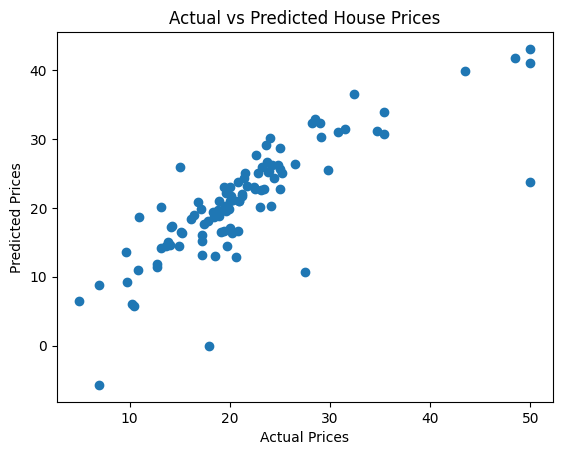

In [24]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

**Predict New Data**

In [26]:
# Example input (13 features)
sample = X.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample)
print("Predicted Price:", prediction[0])

Predicted Price: 30.145267117336918


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
